# Classificação Binária IoT - Detecção de Ocupação de Sala

Dataset UCI Occupancy Detection

### **1. Importações**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

# Bibliotecas para ML
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve)


# Para salvar o modelo
import joblib

### **2. Carregamento do Dataset**

In [ ]:
# Baixando o dataset diretamente do UCI
# https://archive.ics.uci.edu/dataset/357/occupancy+detection
#+----------------+----------+-------------+-------------------------------------------+------------------------------+----------------+
#| Variable Name  | Role     | Type        | Description                               | Units                        | Missing Values |
#+----------------+----------+-------------+-------------------------------------------+------------------------------+----------------+
#| id             | ID       | Integer     |                                           |                              | no             |
#| date           | Feature  | Date        |                                           |                              | no             |
#| Temperature    | Feature  | Integer     |                                           | C                            | no             |
#| Humidity       | Feature  | Continuous  |                                           | %                            | no             |
#| Light          | Feature  | Integer     |                                           | Lux                          | no             |
#| CO2            | Feature  | Continuous  |                                           | ppm                          | no             |
#| HumidityRatio  | Feature  | Continuous  |                                           | kgwater-vapor/kg-air         | no             |
#| Occupancy      | Target   | Binary      | 0 = not occupied, 1 = occupied status     |                              | no             |
#+----------------+----------+-------------+-------------------------------------------+------------------------------+----------------+
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00357/occupancy_data.zip
!unzip -q occupancy_data.zip

replace datatest.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# Carregando os dados de treino
df_train = pd.read_csv('datatraining.txt')
df_test = pd.read_csv('datatest.txt')
df_val = pd.read_csv('datatest2.txt')

# Combinando todos os dados para ter mais amostras
df = pd.concat([df_train, df_test, df_val], ignore_index=True)

print(f"Dataset carregado com sucesso!")
print(f"Total de amostras: {len(df)}")
print(f"Período: {df['date'].min()} até {df['date'].max()}")

Dataset carregado com sucesso!
Total de amostras: 20560
Período: 2015-02-02 14:19:00 até 2015-02-18 09:19:00


### **3. EDA (simples)**

#### Informações gerais do dataset

In [ ]:
print("Primeiras 5 linhas do dataset:")
display(df.head())

print("\nInformações do Dataset:")
display(df.info())

print("\nEstatísticas Descritivas:")
display(df.describe())

Primeiras 5 linhas do dataset:


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1



Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20560 entries, 0 to 20559
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           20560 non-null  object 
 1   Temperature    20560 non-null  float64
 2   Humidity       20560 non-null  float64
 3   Light          20560 non-null  float64
 4   CO2            20560 non-null  float64
 5   HumidityRatio  20560 non-null  float64
 6   Occupancy      20560 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 1.1+ MB


None


Estatísticas Descritivas:


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,20560.000000,20560.000000,20560.000000,20560.000000,20560.000000,20560.000000
mean,20.906212,27.655925,130.756622,690.553276,0.004228,0.231031
std,1.055315,4.982154,210.430875,311.201281,0.000768,0.421503
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,20.200000,24.500000,0.000000,460.000000,0.003719,0.000000
50%,20.700000,27.290000,0.000000,565.416667,0.004292,0.000000
75%,21.525000,31.290000,301.000000,804.666667,0.004832,0.000000
max,24.408333,39.500000,1697.250000,2076.500000,0.006476,1.000000


In [ ]:
# Entendendo os sensores IoT disponíveis
print("\nSensores IoT disponíveis:")
print("- Temperature: Sensor de temperatura (°C)")
print("- Humidity: Sensor de umidade (%)")
print("- Light: Sensor de luminosidade (Lux)")
print("- CO2: Sensor de CO2 (ppm)")
print("- HumidityRatio: Taxa de umidade calculada")
print("- Occupancy: Label (0=vazio, 1=ocupado)")

# Verificando balanceamento das classes
print("\nDistribuição das Classes:")
print(df['Occupancy'].value_counts())
print(f"Proporção: {df['Occupancy'].value_counts(normalize=True).round(2).to_dict()}")


Sensores IoT disponíveis:
- Temperature: Sensor de temperatura (°C)
- Humidity: Sensor de umidade (%)
- Light: Sensor de luminosidade (Lux)
- CO2: Sensor de CO2 (ppm)
- HumidityRatio: Taxa de umidade calculada
- Occupancy: Label (0=vazio, 1=ocupado)

Distribuição das Classes:
Occupancy
0    15810
1     4750
Name: count, dtype: int64
Proporção: {0: 0.77, 1: 0.23}


#### Gráficos

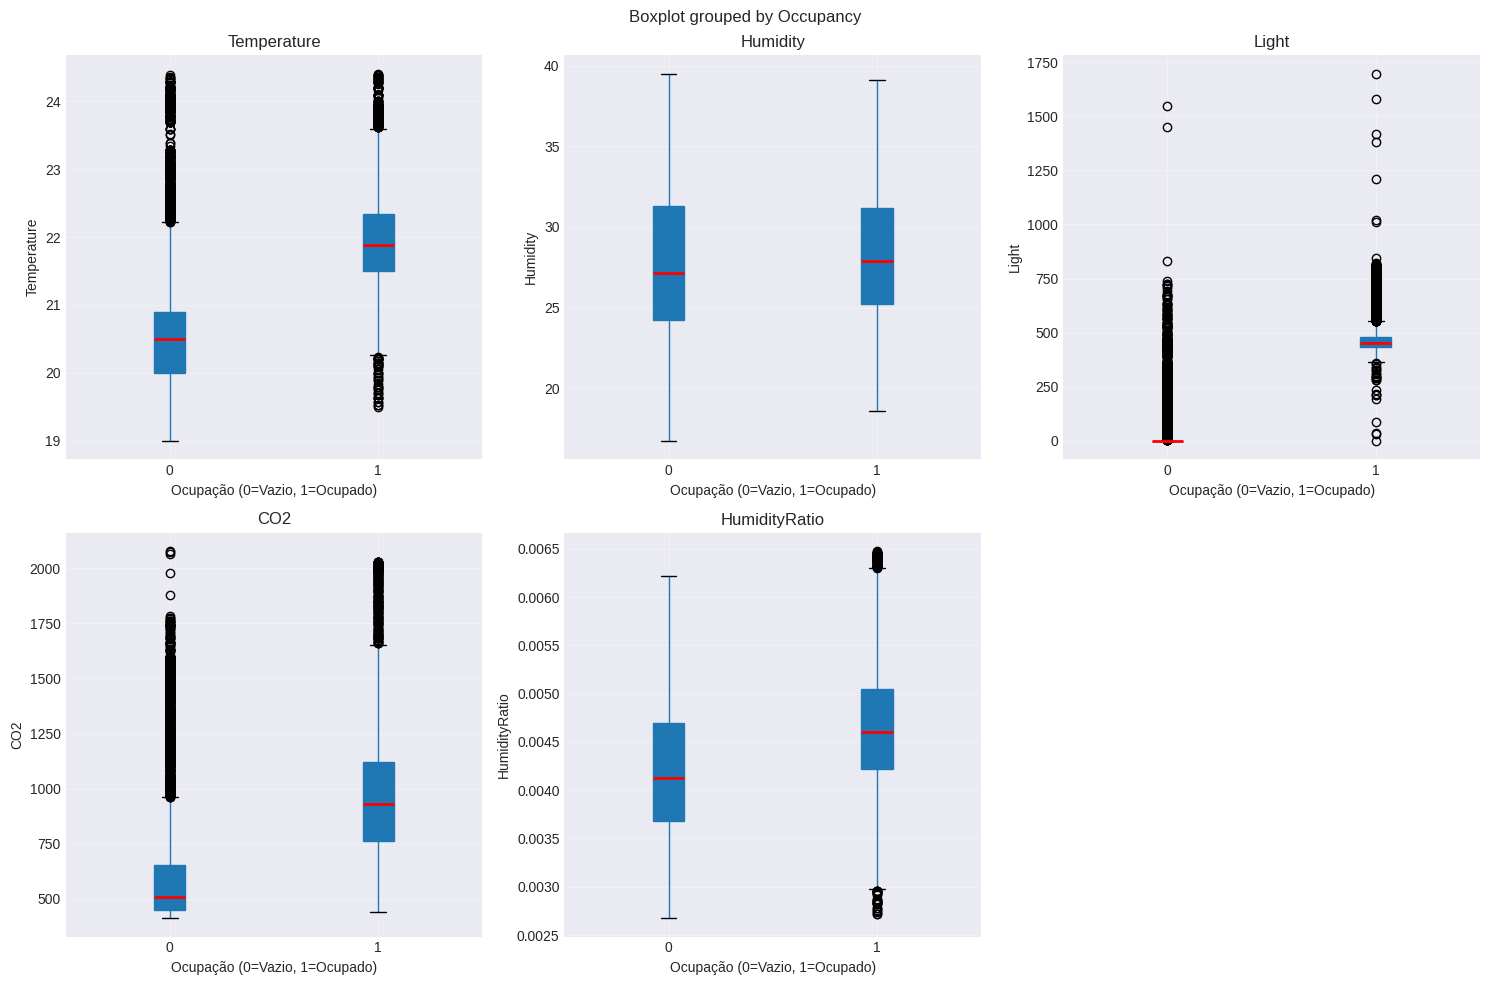

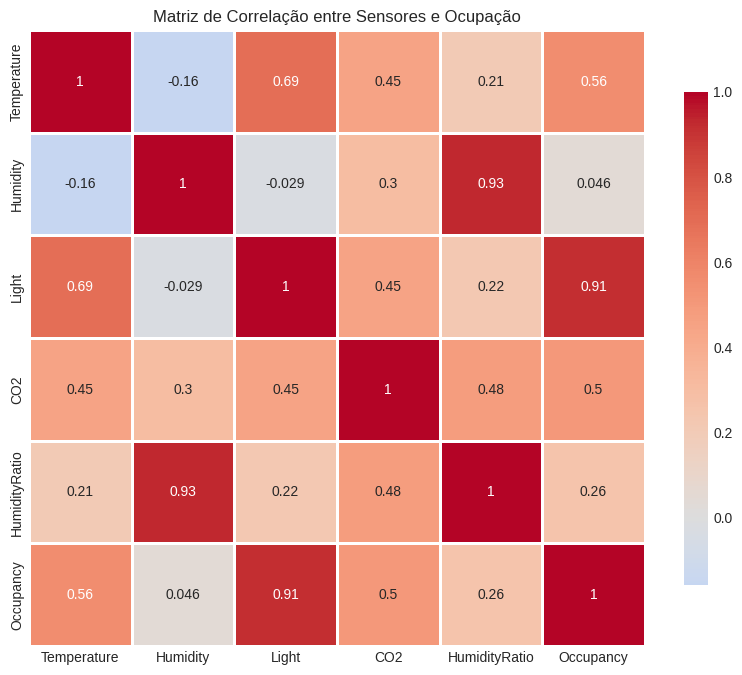

In [ ]:
# Estilo dos gráficos
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análise dos Sensores IoT por Ocupação', fontsize=16)

# Plotando distribuições por sensor
sensors = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
colors = ['#FF6B6B', '#4ECDC4']

for idx, sensor in enumerate(sensors):
    ax = axes[idx//3, idx%3]

    # Boxplot por ocupação
    df.boxplot(column=sensor, by='Occupancy', ax=ax,
              patch_artist=True, medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{sensor}')
    ax.set_xlabel('Ocupação (0=Vazio, 1=Ocupado)')
    ax.set_ylabel(sensor)
    ax.grid(True, alpha=0.3)

# Removendo o subplot vazio
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Matriz de correlação
plt.figure(figsize=(10, 8))
correlation_matrix = df[sensors + ['Occupancy']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação entre Sensores e Ocupação')
plt.show()

### **4. Pipeline: Pré-processamento + Treinamento**

In [ ]:
# Separação entre features e target
feature_columns = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
X = df[feature_columns]
y = df['Occupancy']

In [ ]:
# Dividindo em treino e teste (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Dados divididos:")
print(f"--> Treino: {len(X_train)} amostras")
print(f"--> Teste: {len(X_test)} amostras")
print(f"--> Features: {', '.join(feature_columns)}")

Dados divididos:
--> Treino: 14392 amostras
--> Teste: 6168 amostras
--> Features: Temperature, Humidity, Light, CO2, HumidityRatio


In [ ]:
print("Pipeline com múltiplos modelos usando GridSearchCV")

# Pipeline base com placeholder para o classificador
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier())  # Será substituído pelo GridSearchCV
])

# Configuração de Cross-Validation estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid de parâmetros para múltiplos modelos
param_grid_multi = [
    # Random Forest
    {
        'clf': [RandomForestClassifier(random_state=255, n_jobs=-1)],
        'clf__n_estimators': [10, 50, 75],
        'clf__max_depth': [5, 10, None],
        #'clf__min_samples_split': [2, 5],
        'clf__min_samples_leaf': [1, 2]
    },

    # 4. XGBoost
    {
        'clf': [XGBClassifier(random_state=255, eval_metric='logloss', use_label_encoder=False)],
        'clf__n_estimators': [10, 50, 75],
        'clf__max_depth': [3, 5],
        'clf__learning_rate': [0.01, 0.3],
        'clf__subsample': [0.8, 1.0]
    },

    # 5. LightGBM
    {
        'clf': [LGBMClassifier(random_state=255, verbose=-1)],
        'clf__n_estimators': [10, 50, 75],
        'clf__num_leaves': [10, 31, 50],
        'clf__learning_rate': [0.01, 0.3]
        #'clf__feature_fraction': [0.8, 1.0]
    }
]

# GridSearchCV com todos os modelos
print("Início do treinamento")

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid_multi,
    cv=cv,
    scoring='roc_auc',  # Métrica principal para classificação binária
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Treinamento
grid_search.fit(X_train, y_train)
print("Fim do treinamento")


Pipeline com múltiplos modelos usando GridSearchCV
Início do treinamento
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Fim do treinamento


### **5. Resultado do GridSearchCV (melhor modelo)**

In [ ]:
# Melhor modelo encontrado
best_model = grid_search.best_estimator_.named_steps['clf']
best_model_name = type(best_model).__name__

print(f"\nMelhor Modelo: {best_model_name}")
print(f"Melhor Score: {grid_search.best_score_:.4f}")
print(f"\nMelhores Hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    if param.startswith('clf__'):
        print(f" --> {param.replace('clf__', '')}: {value}")

# Top 5 melhores combinações
resultadoGridSearchCV = pd.DataFrame(grid_search.cv_results_)
resultadoGridSearchCV \
  .loc[:, ['rank_test_score', 'mean_fit_time', 'mean_test_score', 'params']] \
  .sort_values(by='mean_test_score', ascending=False) \
  .head(5)


Melhor Modelo: XGBClassifier
Melhor Score: 0.9991

Melhores Hiperparâmetros:
 --> learning_rate: 0.3
 --> max_depth: 5
 --> n_estimators: 75
 --> subsample: 0.8


,rank_test_score,mean_fit_time,mean_test_score,params
40,1,0.176226,0.999071,"{'clf': XGBClassifier(base_score=None, booster..."
38,2,0.123000,0.998952,"{'clf': XGBClassifier(base_score=None, booster..."
11,3,1.183643,0.998869,"{'clf': RandomForestClassifier(n_jobs=-1, rand..."
41,4,0.146660,0.998856,"{'clf': XGBClassifier(base_score=None, booster..."
10,5,0.821160,0.998852,"{'clf': RandomForestClassifier(n_jobs=-1, rand..."


### **6. Avaliação do melhor modelo**


Métricas de Performance:
 --> Acurácia: 0.9916 (99.16%)
 --> AUC-ROC: 0.9990

Relatório de Classificação:
              precision    recall  f1-score   support

  Sala Vazia     0.9958    0.9933    0.9945      4743
Sala Ocupada     0.9777    0.9860    0.9818      1425

    accuracy                         0.9916      6168
   macro avg     0.9868    0.9896    0.9882      6168
weighted avg     0.9916    0.9916    0.9916      6168



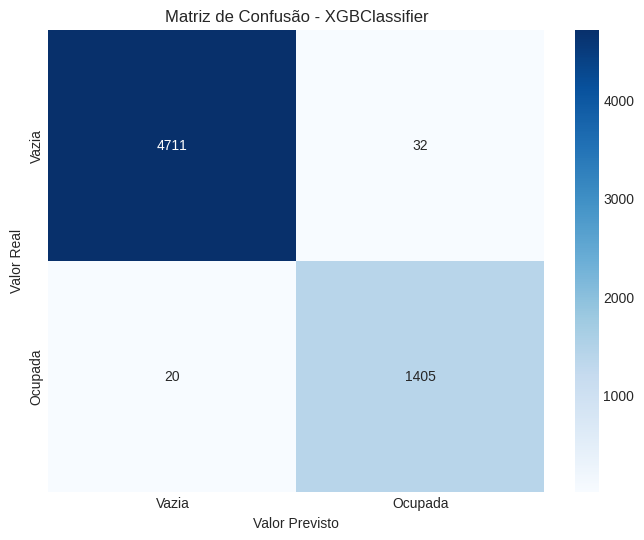

In [ ]:
# Previsões com o melhor modelo
y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)[:, 1]

# Métricas
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nMétricas de Performance:")
print(f" --> Acurácia: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" --> AUC-ROC: {auc_score:.4f}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred,
                          target_names=['Sala Vazia', 'Sala Ocupada'],
                          digits=4))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vazia', 'Ocupada'],
            yticklabels=['Vazia', 'Ocupada'])
plt.title(f'Matriz de Confusão - {best_model_name}')
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto')
plt.show()

### **7. Salvamento e verificação do modelo para deployment**

#### Salvamento

In [ ]:
# Salvando o pipeline completo (scaler + modelo)
nome_arquivo = f'modelo_ocupacao_best_{best_model_name.lower()}.pkl'

print(f"Salvando modelo: {nome_arquivo}")
joblib.dump(grid_search.best_estimator_, nome_arquivo)

# Salvando também os resultados do grid search
resultados_arquivo = 'grid_search_results.pkl'
joblib.dump(grid_search.cv_results_, resultados_arquivo)

print(f"Arquivos salvos:")
print(f" --> Modelo: {nome_arquivo} ({os.path.getsize(nome_arquivo) / 1024:.2f} KB)")
print(f" --> Resultados: {resultados_arquivo} ({os.path.getsize(resultados_arquivo) / 1024:.2f} KB)")

Salvando modelo: modelo_ocupacao_best_xgbclassifier.pkl
Arquivos salvos:
 --> Modelo: modelo_ocupacao_best_xgbclassifier.pkl (125.20 KB)
 --> Resultados: grid_search_results.pkl (17.47 KB)


#### Verificação

In [ ]:
# Verificação
print("\nTestando carregamento do modelo...")
modelo_carregado = joblib.load(nome_arquivo)

# Teste com uma amostra
amostra_teste = X_test.iloc[0:1]
predicao = modelo_carregado.predict(amostra_teste)[0]
probabilidade = modelo_carregado.predict_proba(amostra_teste)[0]

print(f"Modelo carregado")
print(f"\nVerificação com uma amostra:")
print(f" --> Medição dos Sensores: \n{amostra_teste}")
print(f"\n --> Previsão: {'Sala Ocupada' if predicao == 1 else 'Sala Vazia'}")
print(f"\n --> Probabilidades: Vazia={probabilidade[0]:.2%}, Ocupada={probabilidade[1]:.2%}")


Testando carregamento do modelo...
Modelo carregado

Verificação com uma amostra:
 --> Medição dos Sensores: 
       Temperature  Humidity       Light         CO2  HumidityRatio
19189        21.29     31.29  428.333333  978.666667       0.004902

 --> Previsão: Sala Ocupada

 --> Probabilidades: Vazia=0.41%, Ocupada=99.59%


In [ ]:
nova_medicao = pd.DataFrame([{
    'Temperature': 24,
    'Humidity': 40,
    'Light': 472.4,
    'CO2': 413.0,
    'HumidityRatio': 0.003954
}])

# 1. Extraindo o objeto scaler treinado do modelo carregado
scaler_carregado = modelo_carregado.named_steps['scaler']

# 2. Transformando a nova medição
medicao_escalada = scaler_carregado.transform(nova_medicao)

# 3. Convertendo de volta para DataFrame para visualização
medicao_escalada_df = pd.DataFrame(
    medicao_escalada,
    columns=nova_medicao.columns
)

print(" --> Medição Original (nova_medicao):")
print(nova_medicao)
print("\n --> Medição Transformada (medicao_escalada_df):")
print(medicao_escalada_df)

predicao = modelo_carregado.predict(nova_medicao)[0]

probabilidade = modelo_carregado.predict_proba(nova_medicao)[0]

print(f"\n --> Previsão: {'Sala Ocupada' if predicao == 1 else 'Sala Vazia'}")
print(f"\n --> Probabilidades: Vazia={probabilidade[0]:.2%}, Ocupada={probabilidade[1]:.2%}")

 --> Medição Original (nova_medicao):
   Temperature  Humidity  Light    CO2  HumidityRatio
0           24        40  472.4  413.0       0.003954

 --> Medição Transformada (medicao_escalada_df):
   Temperature  Humidity     Light       CO2  HumidityRatio
0     2.934853  2.485224  1.619869 -0.889135      -0.352026

 --> Previsão: Sala Vazia

 --> Probabilidades: Vazia=84.06%, Ocupada=15.94%
